# RAG Ingest and Query

Ingest local docs into the RAG vector store and query them in-process.


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
for cand in [repo_root, *repo_root.parents]:
    if (cand / 'app').exists():
        repo_root = cand
        break
sys.path.insert(0, str(repo_root))
print('Repo root:', repo_root)


Repo root: /Users/pratik_n/Desktop/MyComputer/Sentifargo


## Data requirements

Place .md or .txt files in data/docs/. The ingest step builds embeddings under data/embeddings/.


## Document inventory


In [2]:
from pathlib import Path

docs_dir = repo_root / 'data' / 'docs'
print('Docs dir:', docs_dir, 'exists=', docs_dir.exists())
if docs_dir.exists():
    docs = [p for p in docs_dir.rglob('*') if p.suffix.lower() in {'.md', '.txt'}]
    print('Doc count:', len(docs))
    for p in docs[:5]:
        print('-', p.name)


Docs dir: /Users/pratik_n/Desktop/MyComputer/Sentifargo/data/docs exists= True
Doc count: 6
- fraud_detection.md
- skill_maps.txt
- job_roles.md
- cybersecurity.md
- test_rag_upload.txt


## Links to code


- RAG ingest: `app/rag/ingest.py`


- Retriever: `app/rag/retriever.py`


- API endpoints: `POST /api/rag/ingest`, `POST /api/rag/upload`


In [3]:
# Update paths if your data lives elsewhere.



In [4]:
docs_dir = repo_root / 'data' / 'docs'
print('Docs dir exists:', docs_dir.exists(), docs_dir)


Docs dir exists: True /Users/pratik_n/Desktop/MyComputer/Sentifargo/data/docs


## Ingest documents


In [5]:
from app.rag.ingest import ingest_all_docs
chunks = ingest_all_docs()
print('Chunks ingested:', chunks)


Chunks ingested: 11


## Retrieve context for a query


In [6]:
from app.rag.retriever import retrieve_context
query = 'Summarize fraud detection signals.'
results = retrieve_context(query, top_k=3)
for idx, hit in enumerate(results, start=1):
    print(f'[{idx}]', hit.get('source'), hit.get('text', '')[:200])


[1] /Users/pratik_n/Desktop/MyComputer/Sentifargo/data/docs/fraud_detection.md # Fraud Detection Knowledge Base ## What is Fraud Detection? Fraud detection is the process of identifying unauthorized transactions, identity theft, and financial crimes using data analysis and machi
[2] /Users/pratik_n/Desktop/MyComputer/Sentifargo/data/docs/fraud_detection.md me location - **Time-based patterns**: Transactions at unusual hours - **Velocity patterns**: Multiple rapid transactions - **Device fingerprints**: Unknown or suspicious devices ## Machine Learning f
[3] /Users/pratik_n/Desktop/MyComputer/Sentifargo/data/docs/fraud_detection.md regularly ## Sentifargo Fraud Features - Real-time fraud scoring (0-1 probability) - SHAP explainability (top feature contributions) - Historical pattern analysis - Risk level classification (LOW/M


## Visuals and metrics


/var/folders/pk/ksqc41pj60q3589gfwhqz5tw0000gn/T/ipykernel_47588/3343027450.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


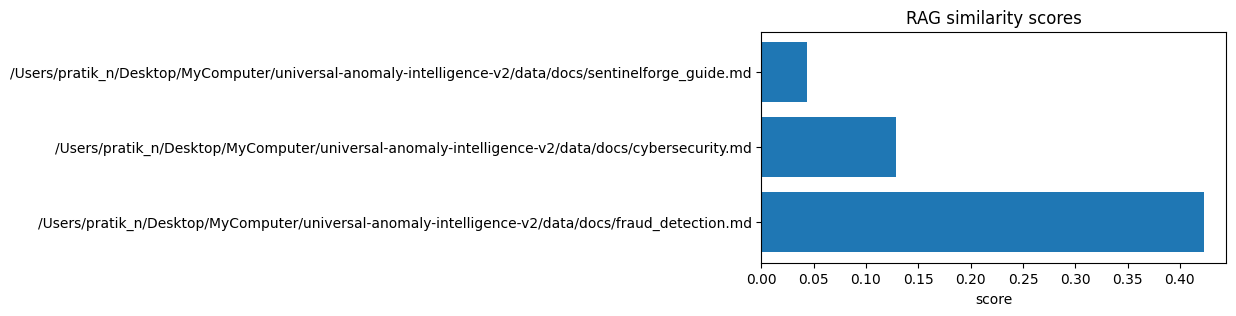

/Users/pratik_n/Desktop/MyComputer/Sentifargo/data/docs/fraud_detection.md score= 0.42320736951515897
/Users/pratik_n/Desktop/MyComputer/Sentifargo/data/docs/fraud_detection.md score= 0.31524416249564025
/Users/pratik_n/Desktop/MyComputer/Sentifargo/data/docs/fraud_detection.md score= 0.20412414523193154
/Users/pratik_n/Desktop/MyComputer/Sentifargo/data/docs/cybersecurity.md score= 0.12909944487358058
/Users/pratik_n/Desktop/MyComputer/Sentifargo/data/docs/Sentifargo_guide.md score= 0.043478260869565216


In [7]:
import matplotlib.pyplot as plt
from app.rag.retriever import retrieve_context

query = 'Summarize fraud detection signals.'
results = retrieve_context(query, top_k=5)
if not results:
    print('No RAG results found')
else:
    labels = [r.get('source') or 'chunk-{}'.format(i) for i, r in enumerate(results)]
    scores = [r.get('score', 0.0) for r in results]
    plt.figure(figsize=(6, 3))
    plt.barh(labels, scores)
    plt.title('RAG similarity scores')
    plt.xlabel('score')
    plt.tight_layout()
    plt.show()
    for r in results:
        print(r.get('source'), 'score=', r.get('score'))
